In [1]:
import os ##### with thesis-seg ENV
import matplotlib.pyplot as plt
from skimage.transform import AffineTransform, SimilarityTransform, warp
from skimage.color import rgb2gray, rgb2hed
from skimage import exposure
from tifffile import imread
import numpy as np


In [15]:
def load_HnE_image(folder_path):

    img_data = []
    label_data = []
    
    for _, _, files in os.walk(folder_path):
        for index, file in enumerate(files):
            if file.endswith(".tif") and index < 3: 
                image_path = os.path.join(folder_path, file)
                img_raw = imread(image_path)
                img = np.array(img_raw)[:, :]
                img_data.append(img)

    return img_data

def display_image(img):
    img = img.astype(float)
    img = img / img.max()
    plt.imshow(img, cmap='gray', vmin=0, vmax=1)
    plt.colorbar()                 
    plt.show()

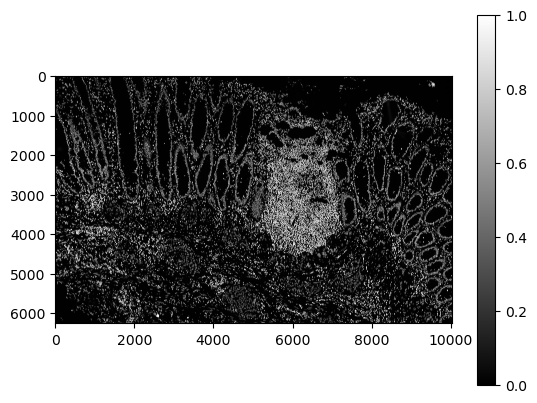

In [17]:
# loading DAPI ROI1
folder_path_dapi = "../../../Thesis_Data/MACSima_HnE_CRC/MACSima_HnE_CRC/CRC027_DAPI"
images_data = load_HnE_image(folder_path_dapi)
roi_1_dapi = images_data[1]
display_image(roi_1_dapi)

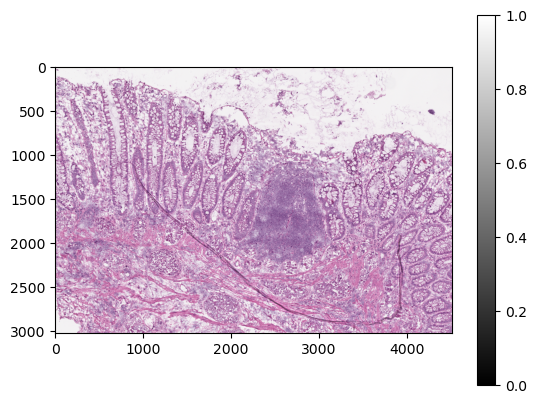

In [16]:
# loading H&E ROI1
folder_path_hne = "../../../Thesis_Data/MACSima_HnE_CRC/MACSima_HnE_CRC/H&E Scans/CRC027"
images_data_hne = load_HnE_image(folder_path_hne)
roi_1_hne = images_data_hne[0]
display_image(roi_1_hne)

## Preprocessing Images

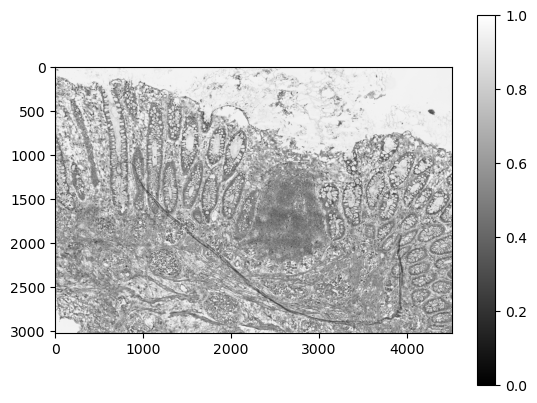

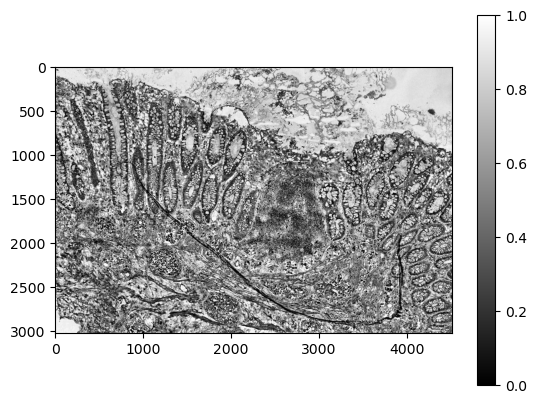

In [19]:
# preprocess H&E image (grayscale and contrast enhancement)
gray_image = rgb2gray(roi_1_hne)
display_image(gray_image)

image = gray_image.astype(float)
gray_image = image / image.max()
gray_enhanced_hne_roi_1 = exposure.equalize_adapthist(gray_image, clip_limit=0.03)
display_image(gray_enhanced_hne_roi_1)

In [ ]:
# preprocess DAPI image 

## Registration using ORB, RANSAC

In [ ]:
# using ORB and RANSAC for registration

import matplotlib.pyplot as plt
from skimage.feature import ORB, match_descriptors, plot_matched_features
from skimage.transform import AffineTransform, warp, resize
from skimage.measure import ransac

# Resize images to be the same size
# image1 = resize(image1, (500, 500), anti_aliasing=True)
# image2 = resize(image2, (500, 500), anti_aliasing=True)

# Initialize ORB detector
orb = ORB(n_keypoints=1000)

# Detect features and descriptors
orb.detect_and_extract(roi_1_dapi)
keypoints1 = orb.keypoints
descriptors1 = orb.descriptors

orb.detect_and_extract(gray_enhanced_hne_roi_1)
keypoints2 = orb.keypoints
descriptors2 = orb.descriptors

# Match descriptors
matches = match_descriptors(descriptors1, descriptors2, cross_check=True)

# Extract matched keypoints
src = keypoints1[matches[:, 0]]
dst = keypoints2[matches[:, 1]]

# Plot keypoints and matches
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
plt.gray()
plot_matched_features(roi_1_dapi, gray_enhanced_hne_roi_1, keypoints0=keypoints1, keypoints1=keypoints2, matches=matches, ax=ax)
ax.axis('off')
ax.set_title("Keypoint Matches")
plt.show()

# Verify number of matches
print(f"Number of matches: {len(matches)}")

# Check if we have enough matches to compute a reliable transformation
if len(matches) < 4:
    raise ValueError("Not enough matches to compute a reliable transformation")

# Compute affine transformation using RANSAC for robustness
model_robust, inliers = ransac((dst, src),
                               AffineTransform, min_samples=4,
                               residual_threshold=2, max_trials=1000)

# Warp image
registered_image = warp(roi_1_dapi, model_robust.inverse, output_shape=gray_enhanced_hne_roi_1.shape)

# Display results
plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1)
plt.title('DAPI ROI 1')
plt.imshow(roi_1_dapi, cmap='gray')

plt.subplot(1, 3, 2)
plt.title('HnE ROI 1')
plt.imshow(gray_enhanced_hne_roi_1, cmap='gray')

plt.subplot(1, 3, 3)
plt.title('Registered Image (aligned version of DAPI ROI 1)')
plt.imshow(registered_image, cmap='gray')

plt.show()

MemoryError: Unable to allocate 333. MiB for an array with shape (5214, 8360) and data type float64